<a href="https://colab.research.google.com/github/iramme/SONAR_TOKEN/blob/main/projet_pretraitementDP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import the packages

In [ ]:
# Import the packages
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import re
import numpy as np
import json  # Ajouté
from collections import Counter
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Configuration des styles
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from wordcloud import WordCloud

# Télécharger les ressources NLTK
try:
    nltk.data.find('tokenizers/punkt')
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('punkt')
    nltk.download('stopwords')

# **Data Collection**


# Read the dataset

we will work with 200000 lignes of the dataset

In [ ]:
data = []
with open("D:/yelp_academic_dataset_review.json", "r", encoding="utf-8") as f:
    for i, line in enumerate(f):
        if i >= 200000:  # 200 000 lignes
            break
        data.append(json.loads(line))

df = pd.DataFrame(data)
df.shape

(200000, 9)

In [ ]:
df.head(10)

,review_id,user_id,business_id,stars,useful,funny,cool,text,date
0,KU_O5udG6zpxOg-VcAEodg,mh_-eMZ6K5RLWhZyISBhwA,XQfwVwDr-v0ZS3_CbbE5Xw,3.0,0,0,0,"If you decide to eat here, just be aware it is...",2018-07-07 22:09:11
1,BiTunyQ73aT9WBnpR9DZGw,OyoGAe7OKpv6SyGZT5g77Q,7ATYjTIgM3jUlt4UM3IypQ,5.0,1,0,1,I've taken a lot of spin classes over the year...,2012-01-03 15:28:18
2,saUsX_uimxRlCVr67Z4Jig,8g_iMtfSiwikVnbP2etR0A,YjUWPpI6HXG530lwP-fb2A,3.0,0,0,0,Family diner. Had the buffet. Eclectic assortm...,2014-02-05 20:30:30
3,AqPFMleE6RsU23_auESxiA,_7bHUi9Uuf5__HHc_Q8guQ,kxX2SOes4o-D3ZQBkiMRfA,5.0,1,0,1,"Wow! Yummy, different, delicious. Our favo...",2015-01-04 00:01:03
4,Sx8TMOWLNuJBWer-0pcmoA,bcjbaE6dDog4jkNY91ncLQ,e4Vwtrqf-wpJfwesgvdgxQ,4.0,1,0,1,Cute interior and owner (?) gave us tour of up...,2017-01-14 20:54:15
5,JrIxlS1TzJ-iCu79ul40cQ,eUta8W_HdHMXPzLBBZhL1A,04UD14gamNjLY0IDYVhHJg,1.0,1,2,1,I am a long term frequent customer of this est...,2015-09-23 23:10:31
6,6AxgBCNX_PNTOxmbRSwcKQ,r3zeYsv1XFBRA4dJpL78cw,gmjsEdUsKpj9Xxu6pdjH0g,5.0,0,2,0,Loved this tour! I grabbed a groupon and the p...,2015-01-03 23:21:18
7,_ZeMknuYdlQcUqng_Im3yg,yfFzsLmaWF2d4Sr0UNbBgg,LHSTtnW3YHCeUkRDGyJOyw,5.0,2,0,0,Amazingly amazing wings and homemade bleu chee...,2015-08-07 02:29:16
8,ZKvDG2sBvHVdF5oBNUOpAQ,wSTuiTk-sKNdcFyprzZAjg,B5XSoSG3SfvQGtKEGQ1tSQ,3.0,1,1,0,This easter instead of going to Lopez Lake we ...,2016-03-30 22:46:33
9,pUycOfUwM8vqX7KjRRhUEA,59MxRhNVhU9MYndMkz0wtw,gebiRewfieSdtt17PTW6Zg,3.0,0,0,0,Had a party of 6 here for hibachi. Our waitres...,2016-07-25 07:31:06


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   review_id    200000 non-null  object 
 1   user_id      200000 non-null  object 
 2   business_id  200000 non-null  object 
 3   stars        200000 non-null  float64
 4   useful       200000 non-null  int64  
 5   funny        200000 non-null  int64  
 6   cool         200000 non-null  int64  
 7   text         200000 non-null  object 
 8   date         200000 non-null  object 
dtypes: float64(1), int64(3), object(5)
memory usage: 13.7+ MB


In [ ]:
df.describe()

,stars,useful,funny,cool
count,200000.000000,200000.000000,200000.000000,200000.000000
mean,3.841425,0.901890,0.257635,0.349225
std,1.357044,2.062767,1.002639,1.077559
min,1.000000,0.000000,0.000000,0.000000
25%,3.000000,0.000000,0.000000,0.000000
50%,4.000000,0.000000,0.000000,0.000000
75%,5.000000,1.000000,0.000000,0.000000
max,5.000000,320.000000,98.000000,49.000000


# 1. Conversion de la colonne en format datetime
La colonne date est de type object (string), il faut la convertir en datetime
errors='coerce' remplace les valeurs incorrectes par NaT (Not a Time), ce qui évite les crashs.)


In [ ]:
# Convertir la colonne en datetime
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# 2. Extraction de l’année et du mois

In [ ]:

# Extraire les informations temporelles
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['year_month'] = df['date'].dt.to_period('M').astype(str)
df['day_of_week'] = df['date'].dt.day_name()


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 13 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   review_id    200000 non-null  object        
 1   user_id      200000 non-null  object        
 2   business_id  200000 non-null  object        
 3   stars        200000 non-null  float64       
 4   useful       200000 non-null  int64         
 5   funny        200000 non-null  int64         
 6   cool         200000 non-null  int64         
 7   text         200000 non-null  object        
 8   date         200000 non-null  datetime64[ns]
 9   year         200000 non-null  int32         
 10  month        200000 non-null  int32         
 11  year_month   200000 non-null  object        
 12  day_of_week  200000 non-null  object        
dtypes: datetime64[ns](1), float64(1), int32(2), int64(3), object(6)
memory usage: 18.3+ MB


# Data Cleaning (Nettoyage des Données)

# 3. Vérification des valeurs manquantes

In [ ]:
df.isnull().sum()

review_id      0
user_id        0
business_id    0
stars          0
useful         0
funny          0
cool           0
text           0
date           0
year           0
month          0
year_month     0
day_of_week    0
dtype: int64

# 4. Vérification des duplication

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
(df['text'].str.strip() == "").sum()

np.int64(0)

In [ ]:
df['length'] = df['text'].str.len()
df[['length']].describe()

,length
count,200000.00000
mean,549.53639
std,504.68102
min,3.00000
25%,225.00000
50%,395.00000
75%,695.00000
max,5000.00000


# 5. Nettoyage du texte

## Vérifier la langue

In [ ]:
from lingua import Language, LanguageDetectorBuilder

languages = [Language.ENGLISH, Language.FRENCH, Language.ARABIC]
detector = LanguageDetectorBuilder.from_languages(*languages).build()

def detect_lang(text):
    lang = detector.detect_language_of(text)
    return lang.name.lower() if lang else "unknown"

df['lang'] = df['text'].astype(str).apply(detect_lang)
df['lang'].value_counts()


lang
english    199927
french         62
unknown        11
Name: count, dtype: int64

In [ ]:
df = df[df['lang'] == 'english']  # on garde seulement anglais
df = df.drop_duplicates(subset='text')  # enlever les doublons


In [ ]:

   import re

def clean_text(text):
    if isinstance(text, str):
        # Convertir en minuscules
        text = text.lower()

        # Supprimer les URLs
        text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)

        # Supprimer les mentions @ et hashtags (#)
        text = re.sub(r'@\w+|\#\w*', '', text)

        # Supprimer la ponctuation
        text = re.sub(r'[^\w\s]', ' ', text)

        # Supprimer les nombres
        text = re.sub(r'\d+', '', text)

        # Supprimer les espaces multiples
        text = re.sub(r'\s+', ' ', text).strip()

        # Stopwords basiques
        stop_words = {
            'the','and','is','in','it','to','of','for','on','with','was','my',
            'i','that','this','but','you','have','are','me','we','they','as'
        }
        text = re.sub(r'[^\w\s]', ' ', text)  # déjà là, mais tu peux étendre si nécessaire
        text = re.sub(r'[^\x00-\x7F]+', ' ', text)  # supprime tout caractère non ASCII (émoticônes)

        # Enlever les stopwords et les mots trop courts
        words = [word for word in text.split() if word not in stop_words and len(word) > 2]

        return ' '.join(words)

    return ""

print("\nNettoyage du texte...")
df['clean_text'] = df['text'].apply(clean_text)


Nettoyage du texte...


In [ ]:
# Afficher les textes originaux et nettoyés

pd.set_option('display.max_colwidth', None)
df[['text', 'clean_text']].head(10)

,text,clean_text
0,"If you decide to eat here, just be aware it is going to take about 2 hours from beginning to end. We have tried it multiple times, because I want to like it! I have been to it's other locations in NJ and never had a bad experience. \n\nThe food is good, but it takes a very long time to come out. The waitstaff is very young, but usually pleasant. We have just had too many experiences where we spent way too long waiting. We usually opt for another diner or restaurant on the weekends, in order to be done quicker.",decide eat here just aware going take about hours from beginning end tried multiple times because want like been other locations never had bad experience food good takes very long time come out waitstaff very young usually pleasant just had too many experiences where spent way too long waiting usually opt another diner restaurant weekends order done quicker
1,"I've taken a lot of spin classes over the years, and nothing compares to the classes at Body Cycle. From the nice, clean space and amazing bikes, to the welcoming and motivating instructors, every class is a top notch work out.\n\nFor anyone who struggles to fit workouts in, the online scheduling system makes it easy to plan ahead (and there's no need to line up way in advanced like many gyms make you do).\n\nThere is no way I can write this review without giving Russell, the owner of Body Cycle, a shout out. Russell's passion for fitness and cycling is so evident, as is his desire for all of his clients to succeed. He is always dropping in to classes to check in/provide encouragement, and is open to ideas and recommendations from anyone. Russell always wears a smile on his face, even when he's kicking your butt in class!",taken lot spin classes over years nothing compares classes body cycle from nice clean space amazing bikes welcoming motivating instructors every class top notch work out anyone who struggles fit workouts online scheduling system makes easy plan ahead there need line way advanced like many gyms make there way can write review without giving russell owner body cycle shout out russell passion fitness cycling evident his desire all his clients succeed always dropping classes check provide encouragement open ideas recommendations from anyone russell always wears smile his face even when kicking your butt class
2,"Family diner. Had the buffet. Eclectic assortment: a large chicken leg, fried jalapeño, tamale, two rolled grape leaves, fresh melon. All good. Lots of Mexican choices there. Also has a menu with breakfast served all day long. Friendly, attentive staff. Good place for a casual relaxed meal with no expectations. Next to the Clarion Hotel.",family diner had buffet eclectic assortment large chicken leg fried jalape tamale two rolled grape leaves fresh melon all good lots mexican choices there also has menu breakfast served all day long friendly attentive staff good place casual relaxed meal expectations next clarion hotel
3,"Wow! Yummy, different, delicious. Our favorite is the lamb curry and korma. With 10 different kinds of naan!!! Don't let the outside deter you (because we almost changed our minds)...go in and try something new! You'll be glad you did!",wow yummy different delicious our favorite lamb curry korma different kinds naan don let outside deter because almost changed our minds try something new glad did
4,"Cute interior and owner (?) gave us tour of upcoming patio/rooftop area which will be great on beautiful days like today. Cheese curds were very good and very filling. Really like that sandwiches come w salad, esp after eating too many curds! Had the onion, gruyere, tomato sandwich. Wasn't too much cheese which I liked. Needed something else...pepper jelly maybe. Would like to see more menu options added such as salads w fun cheeses. Lots of beer and wine as well as limited cocktails. Next time I will try one of the draft wines.",cute interior owner gave tour upcoming patio rooftop area which will great beaut

# 6. verification du text apres le nettoyage

In [ ]:
# 3. Vérifier les textes vides après nettoyage
empty_texts = (df['clean_text'].str.len() == 0).sum()
print(f"Nombre de textes vides après nettoyage: {empty_texts}")

# Supprimer les lignes avec texte vide
df = df[df['clean_text'].str.len() > 0]
print(f"Taille après suppression des textes vides: {df.shape}")

Nombre de textes vides après nettoyage: 0
Taille après suppression des textes vides: (199741, 16)


In [ ]:
df.head()

,review_id,user_id,business_id,stars,useful,funny,cool,text,date,year,month,year_month,day_of_week,length,lang,clean_text
0,KU_O5udG6zpxOg-VcAEodg,mh_-eMZ6K5RLWhZyISBhwA,XQfwVwDr-v0ZS3_CbbE5Xw,3.0,0,0,0,"If you decide to eat here, just be aware it is going to take about 2 hours from beginning to end. We have tried it multiple times, because I want to like it! I have been to it's other locations in NJ and never had a bad experience. \n\nThe food is good, but it takes a very long time to come out. The waitstaff is very young, but usually pleasant. We have just had too many experiences where we spent way too long waiting. We usually opt for another diner or restaurant on the weekends, in order to be done quicker.",2018-07-07 22:09:11,2018,7,2018-07,Saturday,513,english,decide eat here just aware going take about hours from beginning end tried multiple times because want like been other locations never had bad experience food good takes very long time come out waitstaff very young usually pleasant just had too many experiences where spent way too long waiting usually opt another diner restaurant weekends order done quicker
1,BiTunyQ73aT9WBnpR9DZGw,OyoGAe7OKpv6SyGZT5g77Q,7ATYjTIgM3jUlt4UM3IypQ,5.0,1,0,1,"I've taken a lot of spin classes over the years, and nothing compares to the classes at Body Cycle. From the nice, clean space and amazing bikes, to the welcoming and motivating instructors, every class is a top notch work out.\n\nFor anyone who struggles to fit workouts in, the online scheduling system makes it easy to plan ahead (and there's no need to line up way in advanced like many gyms make you do).\n\nThere is no way I can write this review without giving Russell, the owner of Body Cycle, a shout out. Russell's passion for fitness and cycling is so evident, as is his desire for all of his clients to succeed. He is always dropping in to classes to check in/provide encouragement, and is open to ideas and recommendations from anyone. Russell always wears a smile on his face, even when he's kicking your butt in class!",2012-01-03 15:28:18,2012,1,2012-01,Tuesday,829,english,taken lot spin classes over years nothing compares classes body cycle from nice clean space amazing bikes welcoming motivating instructors every class top notch work out anyone who struggles fit workouts online scheduling system makes easy plan ahead there need line way advanced like many gyms make there way can write review without giving russell owner body cycle shout out russell passion fitness cycling evident his desire all his clients succeed always dropping classes check provide encouragement open ideas recommendations from anyone russell always wears smile his face even when kicking your butt class
2,saUsX_uimxRlCVr67Z4Jig,8g_iMtfSiwikVnbP2etR0A,YjUWPpI6HXG530lwP-fb2A,3.0,0,0,0,"Family diner. Had the buffet. Eclectic assortment: a large chicken leg, fried jalapeño, tamale, two rolled grape leaves, fresh melon. All good. Lots of Mexican choices there. Also has a menu with breakfast served all day long. Friendly, attentive staff. Good place for a casual relaxed meal with no expectations. Next to the Clarion Hotel.",2014-02-05 20:30:30,2014,2,2014-02,Wednesday,339,english,family diner had buffet eclectic assortment large chicken leg fried jalape tamale two rolled grape leaves fresh melon all good lots mexican choices there also has menu breakfast served all day long friendly attentive staff good place casual relaxed meal expectations next clarion hotel
3,AqPFMleE6RsU23_auESxiA,_7bHUi9Uuf5__HHc_Q8guQ,kxX2SOes4o-D3ZQBkiMRfA,5.0,1,0,1,"Wow! Yummy, different, delicious. Our favorite is the lamb curry and korma. With 10 different kinds of naan!!! Don't let the outside deter you (because we almost changed our minds)...go in and try something new! You'll be glad you did!",2015-01-04 00:01:03,2015,1,2015-01,Sunday,243,english,wow yummy different delicious our favorite lamb curry korma different kinds naan don let outside deter because almost changed our minds try

# 7. Créer une variable "sentiment"

Pour transformer un problème multi-classes en binaire :

1–2 stars → négatif

3 stars → neutre (on peut retirer si tu veux)

4–5 stars → positif

In [ ]:
def sentiment_label(stars):
    if stars <= 2:
        return "negative"
    elif stars == 3:
        return "neutral"
    else:
        return "positive"

df["sentiment"] = df["stars"].apply(sentiment_label)


In [ ]:
df.head(10)

,review_id,user_id,business_id,stars,useful,funny,cool,text,date,year,month,year_month,day_of_week,length,lang,clean_text,sentiment
0,KU_O5udG6zpxOg-VcAEodg,mh_-eMZ6K5RLWhZyISBhwA,XQfwVwDr-v0ZS3_CbbE5Xw,3.0,0,0,0,"If you decide to eat here, just be aware it is going to take about 2 hours from beginning to end. We have tried it multiple times, because I want to like it! I have been to it's other locations in NJ and never had a bad experience. \n\nThe food is good, but it takes a very long time to come out. The waitstaff is very young, but usually pleasant. We have just had too many experiences where we spent way too long waiting. We usually opt for another diner or restaurant on the weekends, in order to be done quicker.",2018-07-07 22:09:11,2018,7,2018-07,Saturday,513,english,decide eat here just aware going take about hours from beginning end tried multiple times because want like been other locations never had bad experience food good takes very long time come out waitstaff very young usually pleasant just had too many experiences where spent way too long waiting usually opt another diner restaurant weekends order done quicker,neutral
1,BiTunyQ73aT9WBnpR9DZGw,OyoGAe7OKpv6SyGZT5g77Q,7ATYjTIgM3jUlt4UM3IypQ,5.0,1,0,1,"I've taken a lot of spin classes over the years, and nothing compares to the classes at Body Cycle. From the nice, clean space and amazing bikes, to the welcoming and motivating instructors, every class is a top notch work out.\n\nFor anyone who struggles to fit workouts in, the online scheduling system makes it easy to plan ahead (and there's no need to line up way in advanced like many gyms make you do).\n\nThere is no way I can write this review without giving Russell, the owner of Body Cycle, a shout out. Russell's passion for fitness and cycling is so evident, as is his desire for all of his clients to succeed. He is always dropping in to classes to check in/provide encouragement, and is open to ideas and recommendations from anyone. Russell always wears a smile on his face, even when he's kicking your butt in class!",2012-01-03 15:28:18,2012,1,2012-01,Tuesday,829,english,taken lot spin classes over years nothing compares classes body cycle from nice clean space amazing bikes welcoming motivating instructors every class top notch work out anyone who struggles fit workouts online scheduling system makes easy plan ahead there need line way advanced like many gyms make there way can write review without giving russell owner body cycle shout out russell passion fitness cycling evident his desire all his clients succeed always dropping classes check provide encouragement open ideas recommendations from anyone russell always wears smile his face even when kicking your butt class,positive
2,saUsX_uimxRlCVr67Z4Jig,8g_iMtfSiwikVnbP2etR0A,YjUWPpI6HXG530lwP-fb2A,3.0,0,0,0,"Family diner. Had the buffet. Eclectic assortment: a large chicken leg, fried jalapeño, tamale, two rolled grape leaves, fresh melon. All good. Lots of Mexican choices there. Also has a menu with breakfast served all day long. Friendly, attentive staff. Good place for a casual relaxed meal with no expectations. Next to the Clarion Hotel.",2014-02-05 20:30:30,2014,2,2014-02,Wednesday,339,english,family diner had buffet eclectic assortment large chicken leg fried jalape tamale two rolled grape leaves fresh melon all good lots mexican choices there also has menu breakfast served all day long friendly attentive staff good place casual relaxed meal expectations next clarion hotel,neutral
3,AqPFMleE6RsU23_auESxiA,_7bHUi9Uuf5__HHc_Q8guQ,kxX2SOes4o-D3ZQBkiMRfA,5.0,1,0,1,"Wow! Yummy, different, delicious. Our favorite is the lamb curry and korma. With 10 different kinds of naan!!! Don't let the outside deter you (because we almost changed our minds)...go in and try something new! You'll be glad you did!",2015-01-04 00:01:03,2015,1,2015-01,Sunday,243,english,wow yummy different delicious our favorite lamb curry korma different kinds naan don let outside deter b

In [ ]:
df.groupby('sentiment')['clean_text'].count()


sentiment
negative     37987
neutral      22623
positive    139131
Name: clean_text, dtype: int64

# **Data** **Visualization**

# Diagrammes essentiels pour analyser le dataset

# 1️⃣ Distribution des Étoiles (axes[0,0])
Ce diagramme indique la répartition du nombre d'avis par note (1 à 5 étoiles).
# 2️⃣ Distribution du Sentiment (axes[0,1])
Ce que montre ce graphique

Affiche combien d'avis ont été classés comme :
negatif positive ou neutre
# 3️⃣ Distribution par Année (axes[0,2])
Histogramme montrant combien d'avis ont été publiés chaque année.
# 4️⃣ Distribution par Jour de la Semaine (axes[1,0])
Affiche le nombre d'avis publiés chaque jour de la semaine.
# 5️⃣ Longueur du Texte par Sentiment (axes[1,1])
Un boxplot comparant :
la longueur des avis positifs
la longueur des avis neutre
la longueur des avis négatifs
# 6️⃣ Nombre moyen de mots par Note (graph final)
Affiche le nombre moyen de mots dans les avis selon la note d'étoiles.

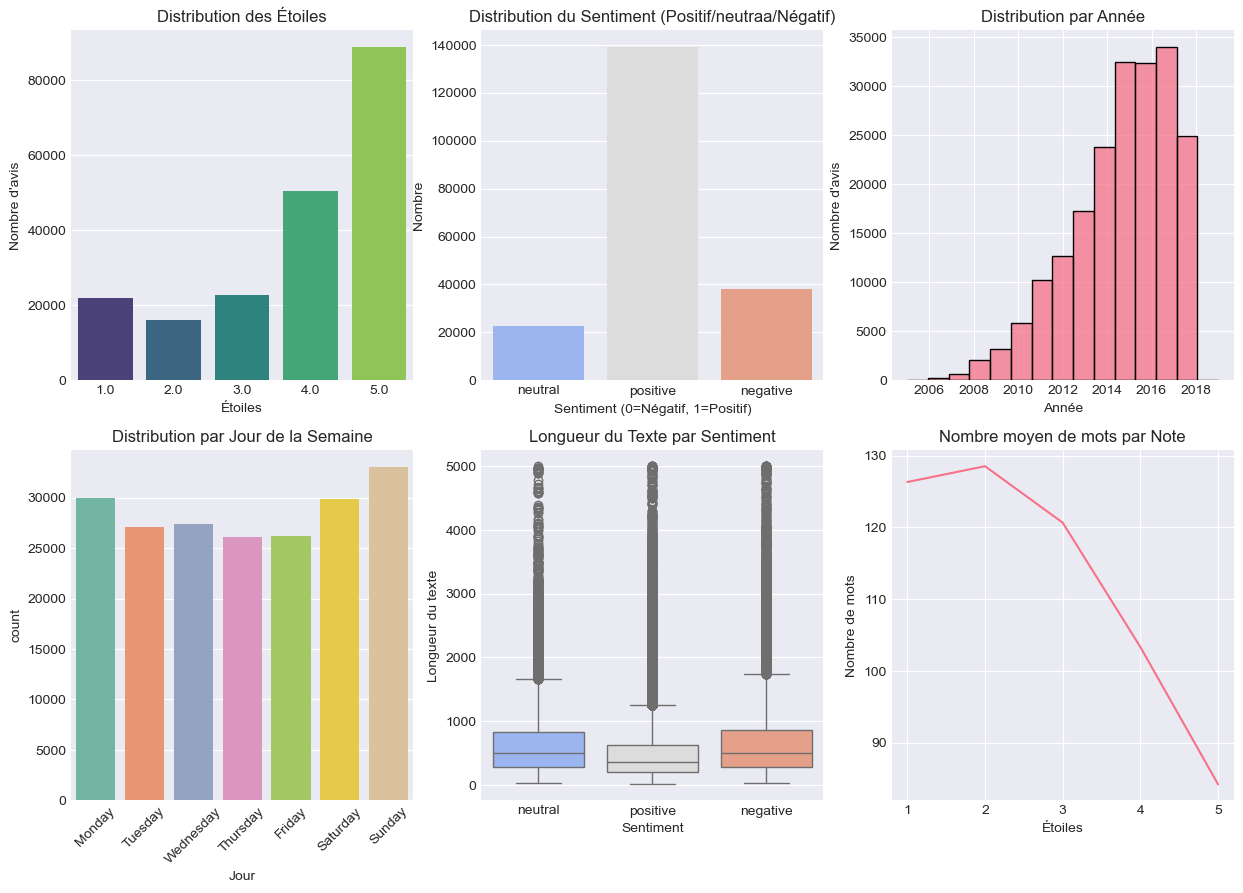

<Figure size 640x480 with 0 Axes>

In [ ]:

# 1. Distribution des étoiles
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Distribution des étoiles
sns.countplot(data=df, x='stars', ax=axes[0, 0], palette='viridis')
axes[0, 0].set_title('Distribution des Étoiles')
axes[0, 0].set_xlabel('Étoiles')
axes[0, 0].set_ylabel('Nombre d\'avis')

# Distribution du sentiment
sns.countplot(data=df, x='sentiment', ax=axes[0, 1], palette='coolwarm')
axes[0, 1].set_title('Distribution du Sentiment (Positif/neutraa/Négatif)')
axes[0, 1].set_xlabel('Sentiment (0=Négatif, 1=Positif)')
axes[0, 1].set_ylabel('Nombre')

# Distribution temporelle
sns.histplot(data=df, x='year', ax=axes[0, 2], bins=len(df['year'].unique()))
axes[0, 2].set_title('Distribution par Année')
axes[0, 2].set_xlabel('Année')
axes[0, 2].set_ylabel('Nombre d\'avis')

# Distribution par jour de la semaine
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
sns.countplot(data=df, x='day_of_week', ax=axes[1, 0], order=weekday_order, palette='Set2')
axes[1, 0].set_title('Distribution par Jour de la Semaine')
axes[1, 0].set_xlabel('Jour')
axes[1, 0].tick_params(axis='x', rotation=45)

# Longueur du texte par sentiment
sns.boxplot(data=df, x='sentiment', y='length', ax=axes[1, 1], palette='coolwarm')
axes[1, 1].set_title('Longueur du Texte par Sentiment')
axes[1, 1].set_xlabel('Sentiment')
axes[1, 1].set_ylabel('Longueur du texte')

# Distribution des votes utiles
df["word_count"] = df["text"].apply(lambda x: len(x.split()))

df.groupby("stars")["word_count"].mean().plot()
plt.title("Nombre moyen de mots par Note")
plt.xlabel("Étoiles")
plt.ylabel("Nombre de mots")
plt.show()

plt.tight_layout()
plt.show()

# Analyse des résultats
1️⃣ Distribution des Étoiles
La majorité des utilisateurs laissent des avis positifs.

Yelp a un biais naturel vers les bonnes expériences, car les clients contents écrivent plus souvent.

Le dataset est déséquilibré vers le positif, ce qui est important pour la modélisation
2️⃣ Distribution du Sentiment (Négatif / Neutre / Positif)
Le sentiment détecté correspond bien à la distribution des étoiles.

Très fort déséquilibre : beaucoup plus d’avis positifs.
3️⃣ Distribution des Avis par Année
Forte croissance entre 2008 et 2015 :

Les avis augmentent chaque année, atteignant un maximum en 2016–2017 (≈ 34 000 avis).

Légère baisse par la suite.
4️⃣ Distribution par Jour de la Semaine
Les avis sont distribués assez uniformément, mais :

Dimanche et Lundi → pics d’activité

Jeudi & Vendredi → jours les moins actifs
Activité stable sur la semaine : les utilisateurs ne dépendant pas d’un jour spécifique pour écrire.
5️⃣ Longueur du Texte par Sentiment
oxplot similaire pour les trois catégories (neutre, positif, négatif), mais :

Les avis négatifs présentent des valeurs un peu plus longues.

Les medians sont proches mais les outliers sont très nombreux (jusqu’à 5000 mots).

✔️ Interprétation

Les avis négatifs sont souvent plus détaillés : les clients expliquent ce qui n’a pas plu.

Les avis positifs ont une forte variabilité (certains très longs, certains très courts).

Les avis neutres restent généralement courts.

6️⃣ Nombre moyen de mots par Note
Les avis 2★ et 1★ sont les plus longs → les clients expriment leur frustration.

Plus la note monte, plus le commentaire devient court.
Insatisfaction → beaucoup de texte

Satisfaction → peu de texte

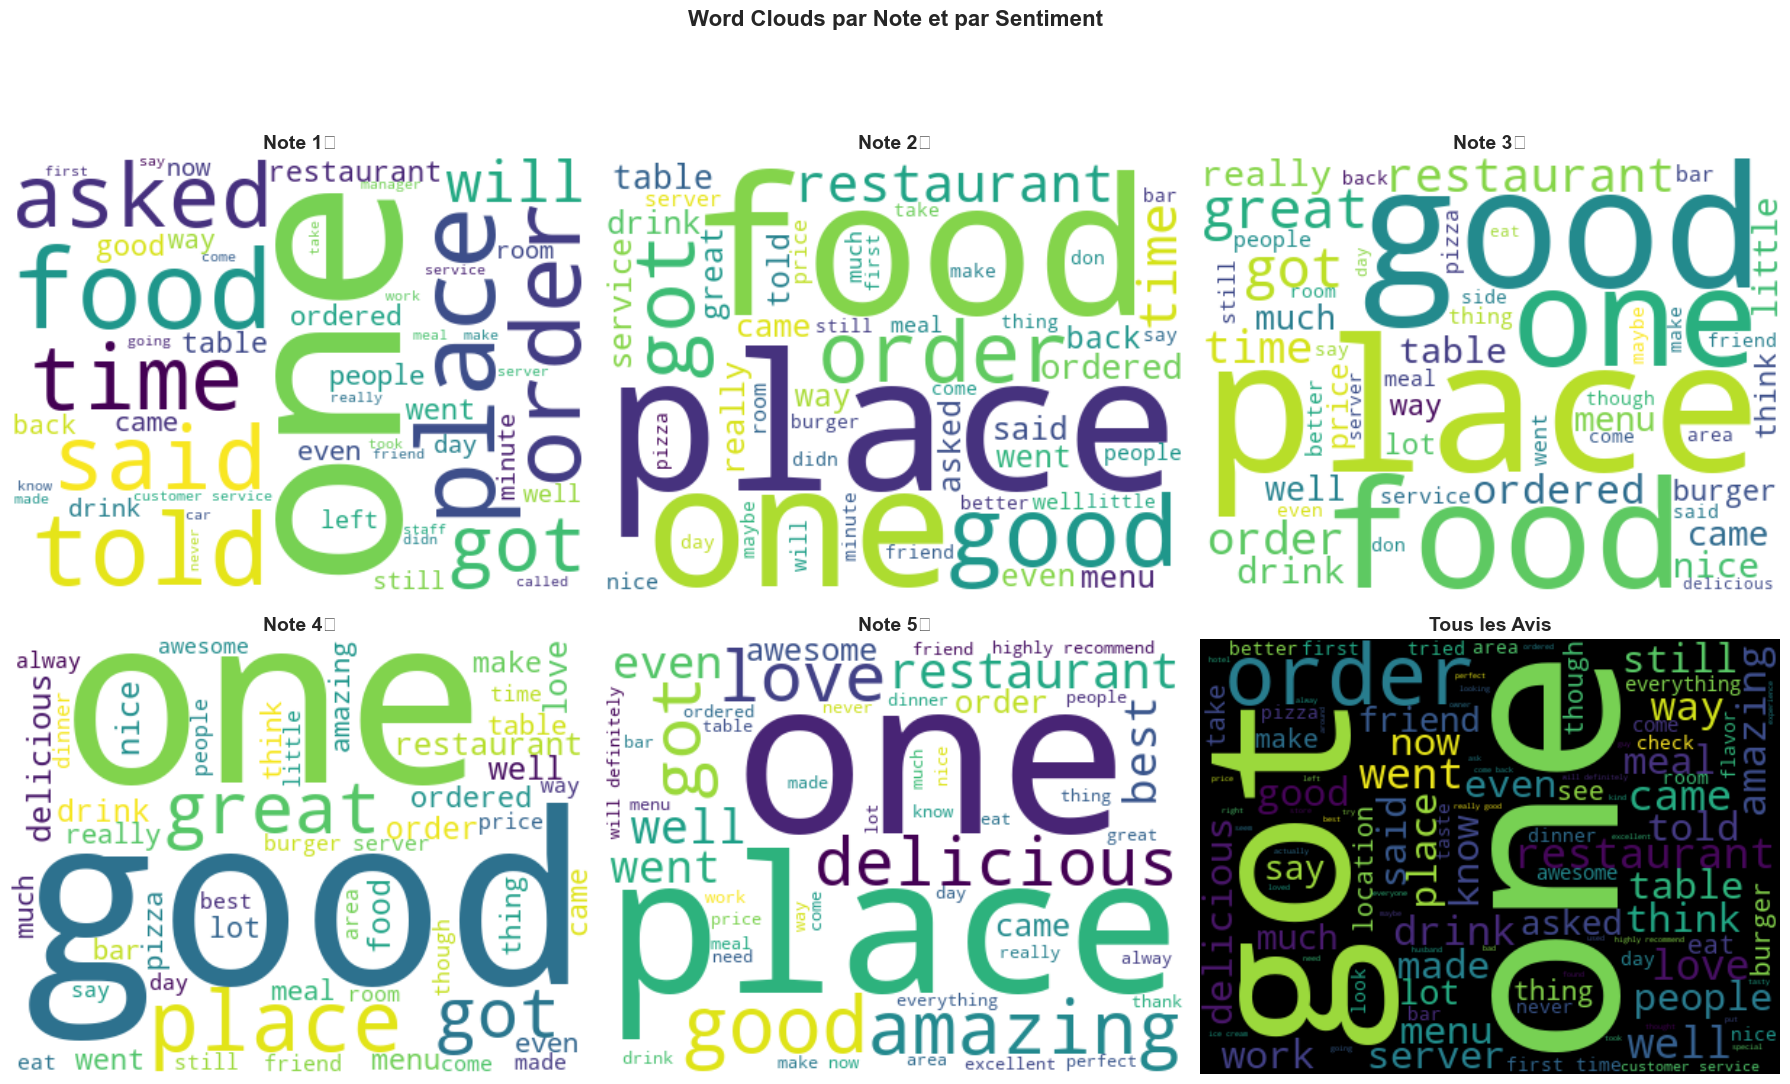

TOP 10 MOTS PAR NOTE

1★ étoiles (21,883 avis):
   1. not               24,393
   2. had               17,691
   3. were              16,437
   4. food              13,111
   5. there             12,839
   6. our               11,859
   7. out               11,283
   8. she               11,045
   9. when              10,593
  10. would             10,069

2★ étoiles (16,104 avis):
   1. not               18,708
   2. were              14,896
   3. had               13,346
   4. food              12,481
   5. there              9,676
   6. good               9,283
   7. our                8,991
   8. just               8,238
   9. place              8,226
  10. like               7,742

3★ étoiles (22,623 avis):
   1. not               21,026
   2. good              18,636
   3. were              18,088
   4. had               16,554
   5. food              16,270
   6. there             12,572
   7. place             12,177
   8. very              10,631
   9. just              10,432

In [ ]:
from collections import Counter
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# --- Génération des Word Clouds par note ---

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Word Clouds par Note et par Sentiment', fontsize=16, fontweight='bold')

ratings = [1, 2, 3, 4, 5]
positions = [(0, 0), (0, 1), (0, 2), (1, 0), (1, 1)]

for rating, pos in zip(ratings, positions):
    rating_text = ' '.join(df[df['stars'] == rating]['text'].astype(str))
    cleaned_text = clean_text(rating_text)
    wordcloud = WordCloud(
        width=400,
        height=300,
        background_color='white',
        max_words=50,
        contour_width=3,
        contour_color='steelblue'
    ).generate(cleaned_text)
    axes[pos[0], pos[1]].imshow(wordcloud, interpolation='bilinear')
    axes[pos[0], pos[1]].axis('off')
    axes[pos[0], pos[1]].set_title(f'Note {rating}★', fontsize=14, fontweight='bold')

# WordCloud global
all_text = ' '.join(df['text'].astype(str))
all_cleaned = clean_text(all_text)
wordcloud_all = WordCloud(
    width=400,
    height=300,
    background_color='black',
    colormap='viridis',
    max_words=100
).generate(all_cleaned)
axes[1, 2].imshow(wordcloud_all, interpolation='bilinear')
axes[1, 2].axis('off')
axes[1, 2].set_title('Tous les Avis', fontsize=14, fontweight='bold')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])  # Ajustement pour le titre principal
plt.show()

# --- Analyse des mots les plus fréquents ---

def get_top_words(text_series, n=10):
    """Récupère les n mots les plus fréquents dans une série de textes"""
    all_text = ' '.join(text_series.astype(str))
    cleaned = clean_text(all_text)
    words = cleaned.split()
    word_counts = Counter(words)
    return word_counts.most_common(n)

print("="*60)
print("TOP 10 MOTS PAR NOTE")
print("="*60)

for rating in [1, 2, 3, 4, 5]:
    rating_text = df[df['stars'] == rating]['text']
    num_reviews = len(rating_text)
    top_words = get_top_words(rating_text, 10)
    print(f"\n{rating}★ étoiles ({num_reviews:,} avis):")
    for i, (word, count) in enumerate(top_words, 1):
        print(f"  {i:2}. {word:15} {count:>8,}")

# --- Comparaison mots négatifs, neutres, positifs ---

print("\n" + "="*60)
print("COMPARAISON MOTS PAR SENTIMENT")
print("="*60)

sentiments = {
    'negative': df[df['stars'].isin([1, 2])]['text'],
    'neutral': df[df['stars'] == 3]['text'],
    'positive': df[df['stars'].isin([4, 5])]['text']
}

top_words_dict = {}
all_sentiment_words = set()

for s, texts in sentiments.items():
    top_words = get_top_words(texts, 15)
    top_words_dict[s] = dict(top_words)
    all_sentiment_words.update([w for w, _ in top_words])

    print(f"\nTop mots dans les avis {s.upper()} ({len(texts):,} avis):")
    for i, (word, count) in enumerate(top_words, 1):
        print(f"  {i:2}. {word:15} {count:>8,}")

# Mots uniques par sentiment
print("\n" + "="*60)
print("MOTS UNIQUES PAR CLASSE")
print("="*60)

for s1 in sentiments:
    others = set()
    for s2 in sentiments:
        if s2 != s1:
            others.update(top_words_dict[s2].keys())

    unique = set(top_words_dict[s1].keys()) - others
    if unique:
        print(f"\nUnique à {s1} ({len(unique)} mots):")
        # Afficher les mots uniques avec leur fréquence
        unique_with_counts = [(word, top_words_dict[s1][word]) for word in unique]
        unique_with_counts.sort(key=lambda x: x[1], reverse=True)

        for word, count in unique_with_counts[:10]:  # Limiter à 10 mots max
            print(f"  • {word:15} {count:>8,}")
    else:
        print(f"\nAucun mot unique pour {s1}")

# --- Analyse supplémentaire : mots communs aux différentes classes ---
print("\n" + "="*60)
print("MOTS COMMUNS ENTRE CLASSES")
print("="*60)

# Mots communs à toutes les classes
common_all = set(top_words_dict['negative'].keys()) & \
             set(top_words_dict['neutral'].keys()) & \
             set(top_words_dict['positive'].keys())

if common_all:
    print(f"\nMots communs aux 3 classes ({len(common_all)} mots):")
    for word in list(common_all)[:15]:  # Limiter l'affichage
        print(f"  • {word}")
else:
    print("\nAucun mot commun aux 3 classes")

# **Data Transformation**

# Encodage des colonnes textuelles/catégorielles

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 199741 entries, 0 to 199999
Data columns (total 18 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   review_id    199741 non-null  object        
 1   user_id      199741 non-null  object        
 2   business_id  199741 non-null  object        
 3   stars        199741 non-null  float64       
 4   useful       199741 non-null  int64         
 5   funny        199741 non-null  int64         
 6   cool         199741 non-null  int64         
 7   text         199741 non-null  object        
 8   date         199741 non-null  datetime64[ns]
 9   year         199741 non-null  int32         
 10  month        199741 non-null  int32         
 11  year_month   199741 non-null  object        
 12  day_of_week  199741 non-null  object        
 13  length       199741 non-null  int64         
 14  lang         199741 non-null  object        
 15  clean_text   199741 non-null  object   

In [ ]:
# Colonnes catégorielles à encoder
cat_cols = ['review_id', 'user_id', 'business_id', 'year_month', 'day_of_week', 'lang', 'sentiment']

# Appliquer LabelEncoder
for col in cat_cols:
    le = LabelEncoder()
    df[col + '_encoded'] = le.fit_transform(df[col])

In [ ]:
# coder texte
vectorizer = TfidfVectorizer(max_features=5000)  # tu peux ajuster max_features
X_text = vectorizer.fit_transform(df['clean_text'])

Si les colonnes ont des plages différentes (par ex. useful varie de 0 à 50 et word_count de 1 à 500), le modèle pourrait être biaisé vers les colonnes avec des valeurs plus grandes.

La normalisation met toutes les colonnes sur la même échelle, ce qui améliore la performance des modèles sensibles à l’échelle.

In [ ]:
scaler = StandardScaler()
numeric_features = ['useful', 'funny', 'cool', 'length', 'word_count']
df[numeric_features] = scaler.fit_transform(df[numeric_features])

transformer les informations temporelles pour que le modèle les comprenne mieux :

is_weekend → indique si l’avis a été écrit un week-end ou pas (comportement des utilisateurs différent selon le jour).

month_sin et month_cos → encode le mois de façon cyclique pour que décembre et janvier soient proches en représentation numérique.

day_sin et day_cos → encode le jour du mois de façon cyclique pour capturer des patterns liés aux jours du mois.

💡 But général : rendre les données temporelles utilisables par le modèle de machine learning en préservant leur nature cyclique

In [ ]:
df['day'] = df['date'].dt.day
df['is_weekend'] = df['day_of_week'].isin(['Saturday', 'Sunday']).astype(int)
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
df['day_sin'] = np.sin(2 * np.pi * df['day'] / 31)
df['day_cos'] = np.cos(2 * np.pi * df['day'] / 31)

In [ ]:
df.shape

(199741, 31)

In [ ]:
df.to_csv("yelp_cleaned_project_pretraitement_1.csv", index=False)
